In [41]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
from shapely.geometry import box
import geopandas as gpd
from rasterio.transform import from_origin

In [2]:
# ── SETUP ───────────────────────────────────
os.chdir("/home/ogallo/Documents/CDE/MSC_thesis/Superresolution-TIR")

L8_PATH = "TIR+LS_test/LC08_L2SP_197028_20230717_20230725_02_T1/LC08_L2SP_197028_20230717_20230725_02_T1_ST_B10.TIF"
QA_PATH = "TIR+LS_test/LC08_L2SP_197028_20230717_20230725_02_T1/LC08_L2SP_197028_20230717_20230725_02_T1_QA_PIXEL.TIF"
HR_PATH = "TIR+LS_test/PDR-2023_TEMP_0.40_v4.tif"

OUT_DIR = "TIR+LS_test/processed"
os.makedirs(OUT_DIR, exist_ok=True)

L8_CLIP  = f"{OUT_DIR}/L8_clip.tif"
QA_CLIP  = f"{OUT_DIR}/QA_clip.tif"
L8_ALIGN = f"{OUT_DIR}/L8_aligned.tif"
QA_ALIGN = f"{OUT_DIR}/QA_aligned.tif"

### REPROJ AND CLIPPING

In [3]:
def clip_to_hr(input_path, hr_path, output_path, buffer=300):
    with rasterio.open(hr_path) as ref:
        bbox = box(*ref.bounds)
        gdf = gpd.GeoDataFrame(geometry=[bbox], crs=ref.crs)

    with rasterio.open(input_path) as src:
        gdf = gdf.to_crs(src.crs)
        geom = [gdf.buffer(buffer).geometry.values[0].__geo_interface__]

        out, transform = mask(src, geom, crop=True)

        meta = src.meta.copy()
        meta.update({
            "height": out.shape[1],
            "width": out.shape[2],
            "transform": transform
        })

    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(out)

    print(f"Clipped: {output_path}")

In [4]:
# Cuts full L8 scene (~185×185km) down to just the Rhône strip area.
# Applied to both ST_B10 and QA_PIXEL so they stay in sync.
 
print("  Clipping L8_B10:")
clip_to_hr(L8_PATH, HR_PATH, L8_CLIP)
 
print("  Clipping QA_PIXEL:")
clip_to_hr(QA_PATH, HR_PATH, QA_CLIP)

  Clipping L8_B10:
Clipped: TIR+LS_test/processed/L8_clip.tif
  Clipping QA_PIXEL:
Clipped: TIR+LS_test/processed/QA_clip.tif


In [5]:
def reproject_lr_to_hr(src_path, hr_path, out_path, resampling):
    with rasterio.open(hr_path) as ref:
        ref_crs = ref.crs
        bounds = ref.bounds

    with rasterio.open(src_path) as src:
        l8_res = src.res[0]   # keep original resolution (~30m)

        # build grid aligned to HR origin
        transform = from_origin(bounds.left, bounds.top, l8_res, l8_res)

        width  = int((bounds.right - bounds.left) / l8_res)
        height = int((bounds.top - bounds.bottom) / l8_res)

        meta = src.meta.copy()
        meta.update({
            "crs": ref_crs,
            "transform": transform,
            "width": width,
            "height": height,
            "dtype": "float32"
        })

        with rasterio.open(out_path, "w", **meta) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=ref_crs,
                    resampling=resampling
                )

    print(f"Aligned: {out_path}")

In [6]:
# HR is in EPSG:2154 (Lambert-93), L8 is in EPSG:32631 (UTM31N).
# We reproject L8 to match HR — HR needs no reprojection.

reproject_lr_to_hr(L8_CLIP, HR_PATH, L8_ALIGN, Resampling.bilinear)
reproject_lr_to_hr(QA_CLIP, HR_PATH, QA_ALIGN, Resampling.nearest)

Aligned: TIR+LS_test/processed/L8_aligned.tif
Aligned: TIR+LS_test/processed/QA_aligned.tif


In [7]:
def verify_alignment(reference_path, aligned_path):
    """
    Verifies alignment between HR and L8.
    At different resolutions they will never have the same
    transform or shape — so we check what actually matters:
      1. Same CRS
      2. Same top-left origin (within 1 pixel tolerance)
      3. L8 extent fully covers HR extent
      4. L8 resolution unchanged (still 30m)
    """
    with rasterio.open(reference_path) as ref:
        ref_crs       = ref.crs
        ref_transform = ref.transform
        ref_bounds    = ref.bounds
        ref_res       = ref.res

    with rasterio.open(aligned_path) as aln:
        aln_crs       = aln.crs
        aln_transform = aln.transform
        aln_bounds    = aln.bounds
        aln_res       = aln.res

    # Check 1 — CRS matches
    crs_ok = ref_crs == aln_crs

    # Check 2 — Origins match within 1 pixel tolerance
    # (ref_transform.c = left, ref_transform.f = top)
    origin_tol = aln_res[0]   # tolerance = 1 L8 pixel width
    origin_ok  = (
        abs(ref_transform.c - aln_transform.c) < origin_tol and
        abs(ref_transform.f - aln_transform.f) < origin_tol
    )

    # Check 3 — L8 extent fully covers HR extent
    # Allow 1 full L8 pixel (30m) tolerance on each side
    # to account for rounding in dimension calculation
    tol = aln_res[0]   # 30m
    covers_ok = (
        aln_bounds.left   <= ref_bounds.left   + tol and
        aln_bounds.right  >= ref_bounds.right  - tol and
        aln_bounds.bottom <= ref_bounds.bottom + tol and
        aln_bounds.top    >= ref_bounds.top    - tol
    )

    # Check 4 — Resolution unchanged
    res_ok = abs(aln_res[0] - 30.0) < 0.01   # within 1cm of 30m

    print(f"  CRS match          : {'ok' if crs_ok    else 'MISMATCH'}")
    print(f"  Origin aligned     : {'ok' if origin_ok else 'MISMATCH'}")
    print(f"  L8 covers HR area  : {'ok' if covers_ok else 'MISMATCH'}")
    print(f"  Resolution 30m     : {'ok' if res_ok    else f'MISMATCH got {aln_res[0]}m'}")
    print(f"\n  HR  origin : ({ref_transform.c:.2f}, {ref_transform.f:.2f})")
    print(f"  L8  origin : ({aln_transform.c:.2f}, {aln_transform.f:.2f})")
    print(f"  L8  resolution : {aln_res[0]}m")

    if crs_ok and origin_ok and covers_ok and res_ok:
        print(f"\n  Alignment confirmed — ready for Step 4")
    else:
        print(f"\n  Alignment failed — check above mismatches")



In [8]:
# Always run this before proceeding to Step 4.
# All three checks must show 

print("Verifying L8 alignment against HR...")
verify_alignment(HR_PATH, L8_ALIGN)

print("\nVerifying QA alignment against HR...")
verify_alignment(HR_PATH, QA_ALIGN)

Verifying L8 alignment against HR...
  CRS match          : ok
  Origin aligned     : ok
  L8 covers HR area  : ok
  Resolution 30m     : ok

  HR  origin : (836008.80, 6514419.20)
  L8  origin : (836008.80, 6514419.20)
  L8  resolution : 30.0m

  Alignment confirmed — ready for Step 4

Verifying QA alignment against HR...
  CRS match          : ok
  Origin aligned     : ok
  L8 covers HR area  : ok
  Resolution 30m     : ok

  HR  origin : (836008.80, 6514419.20)
  L8  origin : (836008.80, 6514419.20)
  L8  resolution : 30.0m

  Alignment confirmed — ready for Step 4


In [10]:
# summary check
# Quick printout of all output file properties.
# Confirm resolutions and shapes look correct before Step 4.
 
print("Output file summary:")
print("=" * 60)
 
files = {
    "HR reprojected" : HR_PATH,
    "L8 aligned"     : L8_ALIGN,
    "QA aligned"     : QA_ALIGN,
}
 
for label, path in files.items():
    with rasterio.open(path) as src:
        print(f"{label}")
        print(f"  CRS        : {src.crs}")
        print(f"  Resolution : {src.res[0]:.2f}m × {src.res[1]:.2f}m")
        print(f"  Shape      : {src.width} × {src.height} pixels")
        print(f"  Dtype      : {src.dtypes[0]}")
        print(f"  Nodata     : {src.nodata}")
        print()


Output file summary:
HR reprojected
  CRS        : EPSG:2154
  Resolution : 0.40m × 0.40m
  Shape      : 26187 × 119391 pixels
  Dtype      : float32
  Nodata     : 3.4028234663852886e+38

L8 aligned
  CRS        : EPSG:2154
  Resolution : 30.00m × 30.00m
  Shape      : 349 × 1591 pixels
  Dtype      : float32
  Nodata     : 0.0

QA aligned
  CRS        : EPSG:2154
  Resolution : 30.00m × 30.00m
  Shape      : 349 × 1591 pixels
  Dtype      : float32
  Nodata     : None



### PATCHING

In [11]:
HR_GT_PATH = "TIR+LS_test/processed/HR_7p5m_GT.tif"
PATCH_DIR  = "TIR+LS_test/processed/patches"
 
# ── Scale factor ──────────────────────────────
SCALE_FACTOR = 4   # 30m → 7.5m, confirmed by supervisor
 
# ── Patch sizes ───────────────────────────────
# HR: 512×512 @ 7.5m = 3840m × 3840m ground coverage
# LR: 128×128 @ 30m  = 3840m × 3840m ground coverage  (×4 ratio ✓)
#
# Why 512×512 HR?
#   The Rhône corridor is narrow (~1km wide on average).
#   Larger patches capture more river per patch and give the
#   model more thermal context to learn from.
#   Confirmed from data: 69 patches with some valid data exist
#   at this size — sufficient for initial testing.
HR_PATCH_SIZE = 512
LR_PATCH_SIZE = HR_PATCH_SIZE // SCALE_FACTOR   # = 128
 
# ── Stride ────────────────────────────────────
# 50% overlap in HR space — maximises patches along the 70km strip
HR_STRIDE = HR_PATCH_SIZE // 2   # = 256 HR pixels
 
# ── QA bit positions (Landsat Collection 2) ──────────────────────────
BIT_CLOUD        = 3
BIT_CLOUD_SHADOW = 4
 
# ── Nodata values ─────────────────────────────
HR_NODATA  = 1e+38    # HR airborne nodata (float32 max)  HOW? 
OUT_NODATA = -9999.0  # standard output nodata convention


In [12]:
#  Downsample HR to 7.5m (GT)
# Creates Ground Truth by downsampling 0.4m HR to 7.5m.
# Bicubic resampling — standard for SR GT generation in literature.
 
print("Downsampling HR → 7.5m")

with rasterio.open(HR_PATH) as src:
    gt_res = 30.0 / SCALE_FACTOR   # 7.5m

    gt_width  = int(round(src.width  * src.res[0] / gt_res))
    gt_height = int(round(src.height * src.res[1] / gt_res))

    gt_transform = from_origin(
        src.transform.c,
        src.transform.f,
        gt_res, gt_res
    )

    meta = src.meta.copy()
    meta.update({
        "width": gt_width,
        "height": gt_height,
        "transform": gt_transform,
        "dtype": "float32"
    })

    with rasterio.open(HR_GT_PATH, "w", **meta) as dst:
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=gt_transform,
            dst_crs=src.crs,
            resampling=Resampling.cubic
        )
 

Downsampling HR → 7.5m


In [17]:
# Parse MTL for L8 scale factors + scene ID
def parse_mtl(mtl_path):
    """Reads Landsat _MTL.txt into a key-value dictionary."""
    mtl = {}
    with open(mtl_path, "r") as f:
        for line in f:
            line = line.strip()
            if "=" not in line or line.startswith("GROUP") or line.startswith("END"):
                continue
            key, value = line.split("=", 1)
            key   = key.strip()
            value = value.strip().strip('"')
            try:
                mtl[key] = float(value)
            except ValueError:
                mtl[key] = value
    return mtl
 
scene_folder = os.path.dirname(L8_PATH)
mtl_files    = [f for f in os.listdir(scene_folder) if f.endswith("_MTL.txt")]
if not mtl_files:
    raise FileNotFoundError(f"No MTL file in {scene_folder}")
 
mtl           = parse_mtl(os.path.join(scene_folder, mtl_files[0]))
ST_B10_SCALE  = mtl["TEMPERATURE_MULT_BAND_ST_B10"]
ST_B10_OFFSET = mtl["TEMPERATURE_ADD_BAND_ST_B10"]
 
# Scene ID from acquisition date — e.g. "20230718"
# Used in patch naming: 20230718_1.tif, 20230718_2.tif ...
# When you add a new scene later, its patches will be 20231005_1.tif etc.
# This keeps the full dataset uniquely named and traceable
SCENE_ID = mtl["DATE_ACQUIRED"].replace("-", "")
 
print(f"MTL file   : {mtl_files[0]}")
print(f"Scene ID   : {SCENE_ID}")
print(f"Scale      : {ST_B10_SCALE}")
print(f"Offset     : {ST_B10_OFFSET}")

MTL file   : LC08_L2SP_197028_20230717_20230725_02_T1_MTL.txt
Scene ID   : 20230717
Scale      : 0.00341802
Offset     : 149.0


In [18]:
#  Helper functions
 
def extract_bit(qa_array, bit_position):
    """Returns boolean array — True where that bit is set."""
    return (qa_array >> bit_position) & 1 == 1
 
 
def to_celsius_l8(arr):
    """
    Converts L8 raw DN to Celsius.
    Formula: celsius = DN * SCALE + OFFSET - 273.15
    Scale and offset retrieved from MTL — no hardcoding.
    """
    return arr.astype(np.float32) * ST_B10_SCALE + ST_B10_OFFSET - 273.15
 
 
def to_celsius_hr(arr):
    """
    HR airborne is already in Celsius — just handle nodata.
    Pixels >= 1e+38 are nodata and set to OUT_NODATA in output.
    Conversion done before any arithmetic to avoid float32 overflow.
    """
    nodata_mask          = arr >= HR_NODATA
    celsius              = arr.copy().astype(np.float32)
    celsius[nodata_mask] = OUT_NODATA
    return celsius
 
 
def save_patch_tif(data, transform, crs, output_path):
    """
    Saves patch as GeoTIFF preserving spatial metadata.
    Spatial metadata lets us trace any patch back to its
    exact ground location — useful for debugging and analysis.
    """
    meta = {
        "driver"    : "GTiff",
        "dtype"     : "float32",
        "width"     : data.shape[1],
        "height"    : data.shape[0],
        "count"     : 1,
        "crs"       : crs,
        "transform" : transform,
        "nodata"    : OUT_NODATA
    }
    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(data.astype(np.float32), 1)

In [59]:
# Compute river-centred patch positions

# Instead of a fixed grid, we follow the river.
# For each row position (at stride intervals), we find where the valid HR data is and centre the patch on it.
# This guarantees every part of the river is covered, including sharp curves and the strip ends.
 
def get_river_col(valid_mask, hr_row, hr_h, hr_w, patch_size):
    row_end = min(hr_row + patch_size, hr_h)
    row_band = valid_mask[hr_row:row_end, :]
    col_counts = row_band.sum(axis=0)
    valid_cols = np.where(col_counts > 0)[0]

    if len(valid_cols) == 0:
        return None

    # Use mode (most frequent column) instead of median
    # river_col = int(valid_cols[np.argmax(col_counts[valid_cols])])

    # Or, use a weighted median
    weights = col_counts[valid_cols]
    river_col = int(np.average(valid_cols, weights=weights))

    hr_col = river_col - patch_size // 2
    hr_col = max(0, min(hr_col, hr_w - patch_size))
    return hr_col
 
print("Computing river-centred patch positions...")
 
with rasterio.open(HR_GT_PATH) as src:
    hr_full  = src.read(1).astype(np.float32)
    hr_h, hr_w = hr_full.shape
 
valid_mask = hr_full < HR_NODATA
 
# Build positions with stride
positions = []
for hr_row in range(0, hr_h - HR_PATCH_SIZE + 1, HR_STRIDE):
    hr_col = get_river_col(valid_mask, hr_row, hr_h, hr_w, HR_PATCH_SIZE)
    if hr_col is not None:
        positions.append((hr_row, hr_col))
 
# Always include last possible row — guarantees bottom is covered
last_row = hr_h - HR_PATCH_SIZE
if positions[-1][0] != last_row:
    hr_col = get_river_col(valid_mask, last_row, hr_h, hr_w, HR_PATCH_SIZE)
    if hr_col is not None:
        positions.append((last_row, hr_col))
 
print(f"  Total positions : {len(positions)}")

Computing river-centred patch positions...
  Total positions : 24


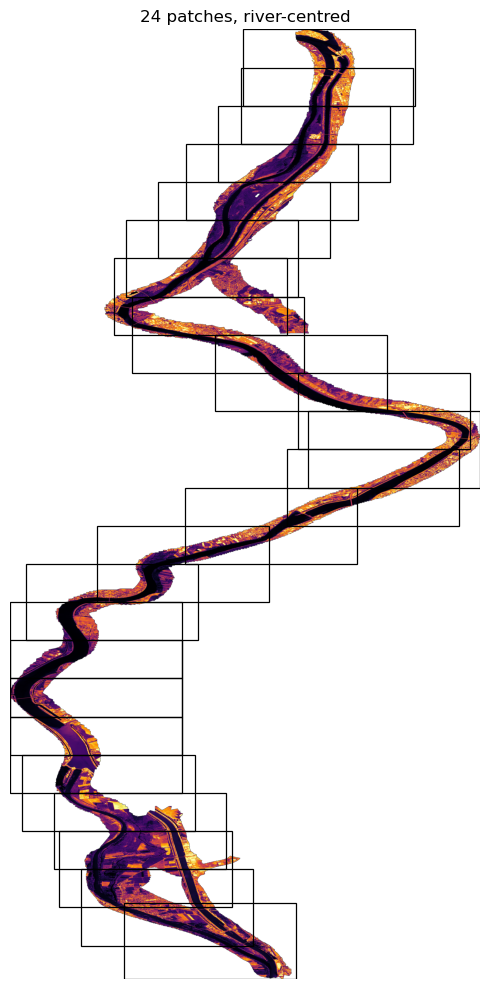

In [60]:
with rasterio.open("TIR+LS_test/processed/HR_7p5m_GT.tif") as src:
    hr     = src.read(1).astype(np.float32)
    hr_h, hr_w = hr.shape

hr = hr.astype(np.float32)
hr[hr >= HR_NODATA] = np.nan

fig, ax = plt.subplots(figsize=(5, 10))

ax.imshow(
    hr,
    cmap="inferno",
    aspect="auto",
    vmin=np.nanpercentile(hr, 2),
    vmax=np.nanpercentile(hr, 98)
)

for r, c in positions:
    ax.add_patch(plt.Rectangle(
        (c, r), HR_PATCH_SIZE, HR_PATCH_SIZE,
        edgecolor="black", facecolor="none", linewidth=0.9
    ))

ax.set_title(f"{len(positions)} patches, river-centred")
ax.axis("off")
plt.tight_layout()
plt.show()

In [61]:
# Extract patch pairs

# Extracts LR/HR patch pairs at river-centred positions.
#
# Units: Celsius throughout
#   L8  : DN → Celsius  (via MTL scale factors)
#   HR  : already Celsius, nodata replaced with -9999
#
# Cloud masking: commented out by default
#   L8 clouds are away from the Rhône for this scene (confirmed visually)
#   Uncomment the cloud check block to enable for future scenes
#
# Naming: {SCENE_ID}_{patch_number}.tif
#   e.g. 20230718_1.tif, 20230718_2.tif ...
#   Future scenes: 20231005_1.tif etc.
 
print(f"\nExtracting patches for scene {SCENE_ID}...")
 
lr_out = os.path.join(PATCH_DIR, "LR")
hr_out = os.path.join(PATCH_DIR, "HR")
 
# Clear existing patches for this scene only
# (keeps patches from other scenes if they exist)
if os.path.exists(os.path.join(PATCH_DIR)):
    shutil.rmtree(os.path.join(PATCH_DIR))
os.makedirs(lr_out, exist_ok=True)
os.makedirs(hr_out, exist_ok=True)
 
with rasterio.open(L8_ALIGN) as lr_src, \
     rasterio.open(HR_GT_PATH)      as hr_src, \
     rasterio.open(QA_ALIGN) as qa_src:
 
    lr_transform = lr_src.transform
    hr_transform = hr_src.transform
    lr_crs       = lr_src.crs
    hr_crs       = hr_src.crs
 
    print("  Reading files...")
    lr_full = lr_src.read(1).astype(np.float32)
    hr_full = hr_src.read(1).astype(np.float32)
    qa_full = qa_src.read(1).astype(np.uint16)
 
lr_h, lr_w = lr_full.shape
 
saved   = 0
skipped = 0
 
for patch_num, (hr_row, hr_col) in enumerate(positions, start=1):
 
    # ── Extract HR patch ──────────────────────
    hr_patch = hr_full[hr_row:hr_row+HR_PATCH_SIZE, hr_col:hr_col+HR_PATCH_SIZE]
 
    # Skip completely empty HR patches
    if (hr_patch >= HR_NODATA).all():
        skipped += 1
        continue
 
    # ── Convert HR pixel → metres → LR pixel ──
    # Using real-world coordinates for accuracy
    hr_x   = hr_transform.c + hr_col * hr_transform.a
    hr_y   = hr_transform.f + hr_row * hr_transform.e
    lr_col = int(round((hr_x - lr_transform.c) / lr_transform.a))
    lr_row = int(round((hr_y - lr_transform.f) / lr_transform.e))
 
    # Skip if LR patch goes out of bounds
    if lr_row < 0 or lr_col < 0 or \
       lr_row + LR_PATCH_SIZE > lr_h or \
       lr_col + LR_PATCH_SIZE > lr_w:
        skipped += 1
        continue
 
    # ── Extract LR and QA patches ─────────────
    lr_patch = lr_full[lr_row:lr_row+LR_PATCH_SIZE, lr_col:lr_col+LR_PATCH_SIZE]
    qa_patch = qa_full[lr_row:lr_row+LR_PATCH_SIZE, lr_col:lr_col+LR_PATCH_SIZE]
 
    # ── Cloud mask (OPTIONAL) ─────────────────
    # Uncomment to skip patches with any cloud or cloud shadow pixels.
    # Currently disabled — L8 clouds confirmed away from Rhône for this scene.
    # Enable for future scenes where cloud coverage over the river is uncertain.
    #
    is_cloud     = extract_bit(qa_patch, BIT_CLOUD)
    is_shadow    = extract_bit(qa_patch, BIT_CLOUD_SHADOW)
    cloud_frac   = (is_cloud | is_shadow).sum() / qa_patch.size

    if cloud_frac > 0.10:   # skip if more than 10% cloudy
        skipped += 1
        continue
 
    # ── Convert to Celsius ────────────────────
    lr_celsius = to_celsius_l8(lr_patch)   # DN → Celsius
    hr_celsius = to_celsius_hr(hr_patch)   # already Celsius, handle nodata
 
    # ── Build patch-level spatial transforms ──
    lr_pt = from_origin(
        lr_transform.c + lr_col * lr_transform.a,
        lr_transform.f + lr_row * lr_transform.e,
        abs(lr_transform.a), abs(lr_transform.e)
    )
    hr_pt = from_origin(
        hr_transform.c + hr_col * hr_transform.a,
        hr_transform.f + hr_row * hr_transform.e,
        abs(hr_transform.a), abs(hr_transform.e)
    )
 
    # ── Save with scene-aware naming ──────────
    # Format: {SCENE_ID}_{patch_number}.tif
    # e.g. 20230718_1.tif, 20230718_2.tif ...
    patch_name = f"{SCENE_ID}_{patch_num}.tif"
 
    save_patch_tif(lr_celsius, lr_pt, lr_crs, os.path.join(lr_out, patch_name))
    save_patch_tif(hr_celsius, hr_pt, hr_crs, os.path.join(hr_out, patch_name))
 
    saved += 1
 
print(f"\n Extraction complete")
print(f"  Scene    : {SCENE_ID}")
print(f"  Saved    : {saved}")
print(f"  Skipped  : {skipped}")
print(f"  LR patches : {lr_out}")
print(f"  HR patches : {hr_out}")


Extracting patches for scene 20230717...
  Reading files...

 Extraction complete
  Scene    : 20230717
  Saved    : 20
  Skipped  : 4
  LR patches : TIR+LS_test/processed/patches/LR
  HR patches : TIR+LS_test/processed/patches/HR


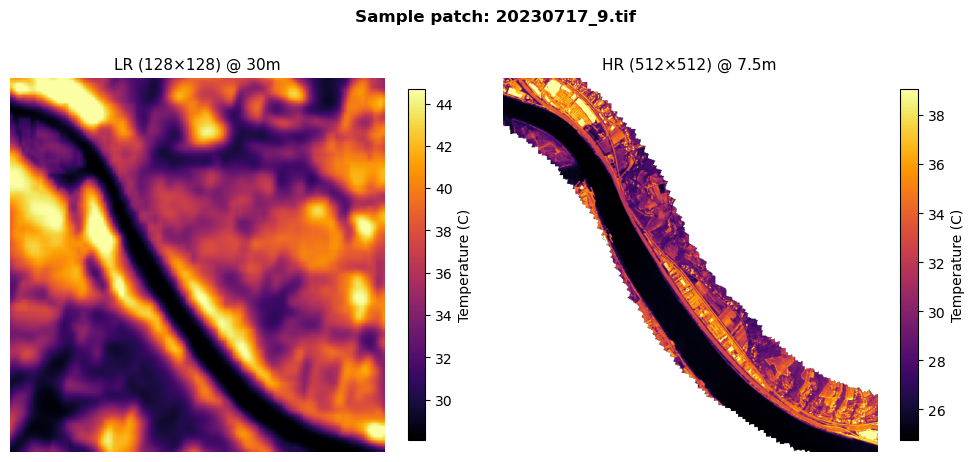

In [66]:
# Sanity check: plot one patch pair
 
train_lr = os.path.join(PATCH_DIR, "LR")
name     = sorted(os.listdir(train_lr))[19]
 
with rasterio.open(os.path.join(PATCH_DIR,  "LR", name)) as s:
    lr = s.read(1).astype(np.float32)
with rasterio.open(os.path.join(PATCH_DIR,  "HR", name)) as s:
    hr = s.read(1).astype(np.float32)
 
lr[lr == -9999] = np.nan
hr[hr == -9999] = np.nan
 
# valid = np.concatenate([lr[~np.isnan(lr)], hr[~np.isnan(hr)]])
# vmin  = np.percentile(valid, 2)
# vmax  = np.percentile(valid, 98)
 
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
 
im0 = axes[0].imshow(lr, cmap="inferno", 
                     vmin=np.percentile(lr[~np.isnan(lr)], 2), 
                     vmax=np.percentile(lr[~np.isnan(lr)], 98))
axes[0].set_title(f"LR ({LR_PATCH_SIZE}×{LR_PATCH_SIZE}) @ 30m", fontsize=11)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], label="Temperature (C)", shrink=0.8)
 
im1 = axes[1].imshow(hr, cmap="inferno", 
                     vmin=np.percentile(hr[~np.isnan(hr)], 2), 
                     vmax=np.percentile(hr[~np.isnan(hr)], 98))
axes[1].set_title(f"HR ({HR_PATCH_SIZE}×{HR_PATCH_SIZE}) @ 7.5m", fontsize=11)
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], label="Temperature (C)", shrink=0.8)
 
plt.suptitle(f"Sample patch: {name}", fontsize=12, fontweight="bold")
plt.tight_layout()